# Quantum Phase Estimation: Precision Scaling
**Course module: AyushDocs-PrecisionScaling**

In this notebook, we study how the precision of Quantum Phase Estimation (QPE) scales with the number of ancilla qubits $n$. This is one of the most critical aspects of designing QPE circuits for practical use.

---

## 1. Theoretical Bound on Precision

With $n$ ancilla qubits, the measurement of the phase register yields an $n$-bit binary string. When decoded as a binary fraction, this gives us $2^n$ possible discrete phase values between $0$ and $1$:

$$\phi \in \left\{ 0, \frac{1}{2^n}, \frac{2}{2^n}, \dots, \frac{2^n - 1}{2^n} \right\}$$

If the true phase $\phi$ is not a dyadic fraction (i.e. it cannot be written exactly as $k/2^n$ for some integer $k$), the estimated phase will suffer from a discretization error. The worst-case error is bounded by:

$$\Delta \phi \le \frac{1}{2^{n}}$$

Thus, each additional ancilla qubit we add to the circuit is expected to halve the error (corresponding to an exponential increase in precision).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator

## 2. Implementing QPE Simulator Pipeline

In [2]:
SIM = AerSimulator()

def qpe_phase_gate(theta, num_ancilla):
    n = num_ancilla
    qc = QuantumCircuit(n + 1, n)
    target = n
    ancillas = list(range(n))
    qc.x(target)
    qc.h(ancillas)
    for j in range(n):
        qc.cp(2**j * theta, ancillas[j], target)
    qc.compose(QFTGate(n).inverse(), ancillas, inplace=True)
    qc.measure(ancillas, list(range(n)))
    return qc

def run_qpe_phase(theta, num_ancilla, shots=20000):
    qc = qpe_phase_gate(theta, num_ancilla)
    qct = transpile(qc, SIM)
    counts = SIM.run(qct, shots=shots).result().get_counts()
    total = sum(counts.values())

    phase_est = 0.0
    for bits, c in counts.items():
        frac = sum(int(bits[i]) / (1 << (i + 1)) for i in range(len(bits)))
        phase_est += frac * c / total

    true_phase = (theta % (2 * np.pi)) / (2 * np.pi)
    raw_err = abs(phase_est - true_phase)
    error = min(raw_err, 1.0 - raw_err)
    return phase_est, true_phase, error

## 3. Sweeping Ancilla Counts

In [3]:
def sweep_precision(theta, max_n=10, shots=20000):
    ns = list(range(1, max_n + 1))
    errs = []
    ests = []
    for n in ns:
        est, true, err = run_qpe_phase(theta, n, shots)
        errs.append(err)
        ests.append(est)
    return ns, errs, ests

## 4. Plotting and Visualizing Precision Scaling

In [4]:
def plot_precision(ns, errs, true_phase, save=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    bound = [1.0 / (1 << n) for n in ns]

    ax1.semilogy(ns, errs, "bo-", ms=6, label="QPE error")
    ax1.semilogy(ns, bound, "r--", lw=2, label=r"$1/2^n$ bound")
    ax1.set_xlabel("Ancilla qubits $n$")
    ax1.set_ylabel("Phase estimation error")
    ax1.set_title("QPE precision scaling")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.semilogy(ns, errs, "bo-", ms=6, label="QPE error")
    ax2.semilogy(ns, bound, "r--", lw=2, label=r"$1/2^n$ bound")
    ax2.set_xlabel("Ancilla qubits $n$")
    ax2.set_ylabel("Error (log scale)")
    ax2.set_title(f"True phase = {true_phase:.4f}")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150)
        print(f"Saved precision scaling plot to {save}")
    plt.show()

## 5. Execution and Verification

Let's sweep $n$ from 1 to 10 for the non-dyadic phase $\phi = 0.4$ (which represents an infinite binary decimal $0.0110011001100\dots$).

  n | Measured Error | Theoretical 1/2ⁿ | Estimated φ
-----------------------------------------------------
  1 |       5.22e-02 |         5.00e-01 |   0.452200
  2 |       1.65e-02 |         2.50e-01 |   0.416525
  3 |       1.73e-02 |         1.25e-01 |   0.382725
  4 |       1.36e-03 |         6.25e-02 |   0.398641
  5 |       5.60e-03 |         3.12e-02 |   0.405595
  6 |       3.17e-03 |         1.56e-02 |   0.403170
  7 |       8.29e-04 |         7.81e-03 |   0.399171
  8 |       1.42e-04 |         3.91e-03 |   0.400142
  9 |       4.12e-04 |         1.95e-03 |   0.400412
 10 |       2.09e-04 |         9.77e-04 |   0.400209


Saved precision scaling plot to ../docs/precision_scaling.png


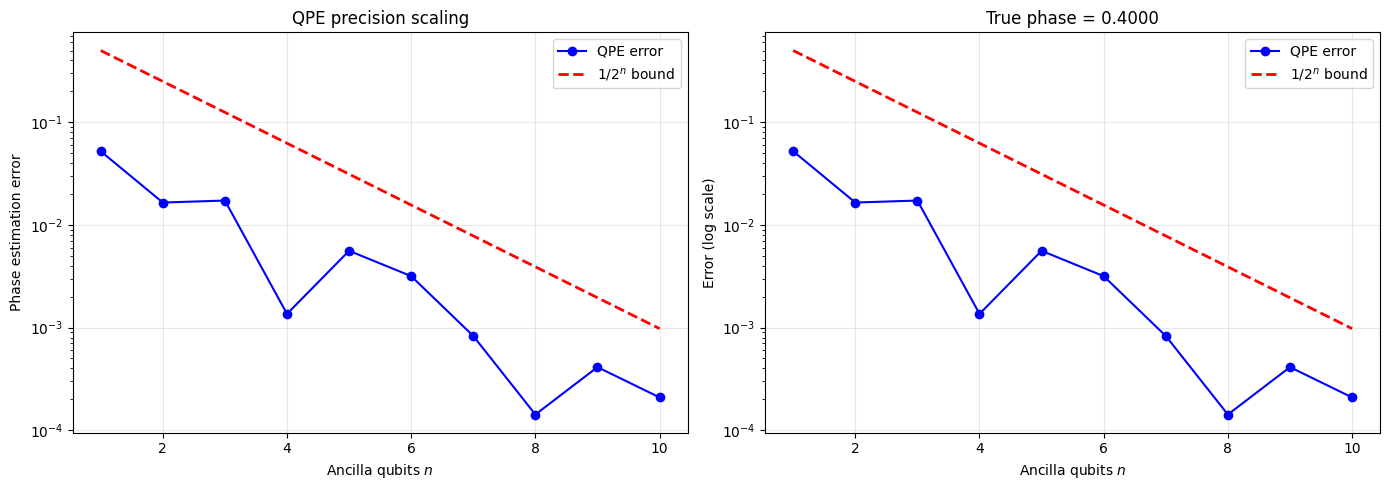

In [5]:
THETA = 2 * np.pi * 0.4
SHOTS = 20000

ns, errs, ests = sweep_precision(THETA, 10, SHOTS)

print(f"{'n':>3} | {'Measured Error':>14} | {'Theoretical 1/2ⁿ':>16} | {'Estimated φ':>10}")
print("-" * 53)
for n, e, ph in zip(ns, errs, ests):
    print(f"{n:3d} | {e:14.2e} | {1/(1<<n):16.2e} | {ph:10.6f}")

plot_precision(ns, errs, 0.4, "../docs/precision_scaling.png")

### Discussion
Observe how the measured QPE error drops exponentially, closely tracing the theoretical $1/2^n$ bound. Since $\phi=0.4$ cannot be written as a terminating binary fraction, we will always have a non-zero estimation error for any finite number of qubits $n$, but we can get arbitrarily close by increasing $n$.